# End-to-End Retail Analytics Platform — Azure Databricks Capstone
## Setup: Create all data files in DBFS

In [0]:
import json

customers_data = """customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium"""

products_data = """product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000"""

orders_data = """order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed"""

preferences_data = json.dumps([
    {"customer_id": "C101", "preferred_channel": "Online", "loyalty": {"tier": "Gold", "points": 1200}},
    {"customer_id": "C102", "preferred_channel": "Store", "loyalty": {"tier": "Silver", "points": 700}},
    {"customer_id": "C104", "preferred_channel": "Online", "loyalty": {"tier": "Platinum", "points": 2200}},
    {"customer_id": "C108", "preferred_channel": "Mobile App", "loyalty": {"tier": "Gold", "points": 1500}}
])

dbutils.fs.put('/FileStore/retail/customers.csv', customers_data, overwrite=True)
dbutils.fs.put('/FileStore/retail/products.csv', products_data, overwrite=True)
dbutils.fs.put('/FileStore/retail/orders.csv', orders_data, overwrite=True)
dbutils.fs.put('/FileStore/retail/customer_preferences.json', preferences_data, overwrite=True)
print('All files created in DBFS!')


Wrote 387 bytes.
Wrote 252 bytes.
Wrote 446 bytes.
Wrote 412 bytes.
All files created in DBFS!


## Part 1: Ingestion

In [0]:
#2 - Read customers.csv
df_customers = spark.read.csv('/FileStore/retail/customers.csv', header=True, inferSchema=True)
display(df_customers)


customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
#3 - Read products.csv
df_products = spark.read.csv('/FileStore/retail/products.csv', header=True, inferSchema=True)
display(df_products)


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


In [0]:
#4 - Read orders.csv
df_orders = spark.read.csv('/FileStore/retail/orders.csv', header=True, inferSchema=True)
display(df_orders)


order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
#5 - Read customer_preferences.json
df_prefs_raw = spark.read.option('multiline', 'true').json('/FileStore/retail/customer_preferences.json')
display(df_prefs_raw)


customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
#6 - Display schema of all datasets
print('customers schema:')
df_customers.printSchema()
print('products schema:')
df_products.printSchema()
print('orders schema:')
df_orders.printSchema()
print('preferences schema:')
df_prefs_raw.printSchema()


customers schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

products schema:
root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

orders schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

preferences schema:
root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
#7 - Save raw data as Bronze Delta tables
spark.sql('DROP TABLE IF EXISTS bronze_customers')
spark.sql('DROP TABLE IF EXISTS bronze_products')
spark.sql('DROP TABLE IF EXISTS bronze_orders')
spark.sql('DROP TABLE IF EXISTS bronze_preferences')

df_customers.write.format('delta').mode('overwrite').saveAsTable('bronze_customers')
df_products.write.format('delta').mode('overwrite').saveAsTable('bronze_products')
df_orders.write.format('delta').mode('overwrite').saveAsTable('bronze_orders')
df_prefs_raw.write.format('delta').mode('overwrite').saveAsTable('bronze_preferences')
print('Bronze Delta tables created!')


Bronze Delta tables created!


## Part 2: Cleaning and Transformation

In [0]:
#8 - Handle null values
from pyspark.sql.functions import col, when, lit, coalesce, date_format

df_orders = df_orders.fillna({'quantity': 1, 'status': 'Unknown'})
df_customers = df_customers.fillna({'customer_type': 'Regular'})
print('Null values handled')


Null values handled


In [0]:
#9 - Flatten customer_preferences.json
df_prefs = df_prefs_raw.select(
    col('customer_id'),
    col('preferred_channel'),
    coalesce(col('loyalty.tier'), lit('N/A')).alias('loyalty_tier'),
    coalesce(col('loyalty.points'), lit(0)).alias('loyalty_points')
)
display(df_prefs)


customer_id,preferred_channel,loyalty_tier,loyalty_points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


In [0]:
#10 - Join customers with preferences
df_customers_prefs = df_customers.join(df_prefs, 'customer_id', 'left')
display(df_customers_prefs)


customer_id,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
#11 - Join orders with customers
df_orders_customers = df_orders.join(
    df_customers.withColumnRenamed('city', 'customer_city'),
    'customer_id', 'inner'
)
display(df_orders_customers)


customer_id,order_id,product_id,order_date,quantity,status,customer_name,customer_city,state,customer_type
C101,O1001,P101,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C102,O1002,P102,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular
C103,O1003,P103,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular
C104,O1004,P104,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium
C105,O1005,P105,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,O1006,P106,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium
C107,O1007,P107,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular
C108,O1008,P108,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium
C101,O1009,P102,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C104,O1010,P101,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium


In [0]:
#12 - Join orders with products
df_full = df_orders_customers.join(df_products, 'product_id', 'inner')
display(df_full)


product_id,customer_id,order_id,order_date,quantity,status,customer_name,customer_city,state,customer_type,product_name,category,unit_price
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000


In [0]:
#13 - Create revenue = quantity * unit_price
df_full = df_full.withColumn('revenue', col('quantity') * col('unit_price'))
display(df_full.select('order_id', 'quantity', 'unit_price', 'revenue'))


order_id,quantity,unit_price,revenue
O1001,1,65000,65000
O1002,2,25000,50000
O1003,3,7000,21000
O1004,2,12000,24000
O1005,4,4500,18000
O1006,1,8000,8000
O1007,1,45000,45000
O1008,5,3000,15000
O1009,1,25000,25000
O1010,1,65000,65000


In [0]:
#14 - Create order_month from order_date
df_full = df_full.withColumn('order_month', date_format(col('order_date'), 'yyyy-MM'))
display(df_full.select('order_id', 'order_date', 'order_month'))


order_id,order_date,order_month
O1001,2026-06-01,2026-06
O1002,2026-06-01,2026-06
O1003,2026-06-02,2026-06
O1004,2026-06-02,2026-06
O1005,2026-06-03,2026-06
O1006,2026-06-03,2026-06
O1007,2026-06-04,2026-06
O1008,2026-06-04,2026-06
O1009,2026-06-05,2026-06
O1010,2026-06-05,2026-06


In [0]:
#15 - Create customer_segment
df_full = df_full.withColumn('customer_segment',
    when(col('customer_type') == 'Premium', 'High Value')
    .otherwise('Standard Value')
)
display(df_full.select('customer_id', 'customer_name', 'customer_type', 'customer_segment'))


customer_id,customer_name,customer_type,customer_segment
C101,Rahul Sharma,Premium,High Value
C102,Priya Reddy,Regular,Standard Value
C103,Amit Kumar,Regular,Standard Value
C104,Sneha Patel,Premium,High Value
C105,Farhan Ali,Regular,Standard Value
C106,Neha Singh,Premium,High Value
C107,Arjun Verma,Regular,Standard Value
C108,Meera Nair,Premium,High Value
C101,Rahul Sharma,Premium,High Value
C104,Sneha Patel,Premium,High Value


In [0]:
#16 - Save cleaned data as Silver Delta tables
spark.sql('DROP TABLE IF EXISTS silver_orders_full')
spark.sql('DROP TABLE IF EXISTS silver_customers_prefs')

df_full.write.format('delta').mode('overwrite').saveAsTable('silver_orders_full')
df_customers_prefs.write.format('delta').mode('overwrite').saveAsTable('silver_customers_prefs')
print('Silver Delta tables created!')


Silver Delta tables created!


## Part 3: Spark SQL

In [0]:
#17 - Create temporary views
df_full.createOrReplaceTempView('orders_view')
df_customers.createOrReplaceTempView('customers_view')
df_products.createOrReplaceTempView('products_view')
print('Temp views created')


Temp views created


In [0]:
#18 - Total revenue
spark.sql('SELECT SUM(revenue) AS total_revenue FROM orders_view').show()


+-------------+
|total_revenue|
+-------------+
|       336000|
+-------------+



In [0]:
#19 - Revenue by city
spark.sql("""
    SELECT customer_city AS city, SUM(revenue) AS revenue
    FROM orders_view
    GROUP BY customer_city
    ORDER BY revenue DESC
""").show()


+---------+-------+
|     city|revenue|
+---------+-------+
|Hyderabad| 135000|
|    Delhi|  89000|
|Bangalore|  50000|
|   Mumbai|  21000|
|  Chennai|  18000|
|    Kochi|  15000|
|     Pune|   8000|
+---------+-------+



In [0]:
#20 - Revenue by category
spark.sql("""
    SELECT category, SUM(revenue) AS revenue
    FROM orders_view
    GROUP BY category
    ORDER BY revenue DESC
""").show()


+-----------+-------+
|   category|revenue|
+-----------+-------+
|Electronics| 250000|
|  Furniture|  45000|
|    Fashion|  41000|
+-----------+-------+



In [0]:
#21 - Top customers by revenue
spark.sql("""
    SELECT customer_id, customer_name, SUM(revenue) AS total_revenue
    FROM orders_view
    GROUP BY customer_id, customer_name
    ORDER BY total_revenue DESC
    LIMIT 5
""").show()


+-----------+-------------+-------------+
|customer_id|customer_name|total_revenue|
+-----------+-------------+-------------+
|       C101| Rahul Sharma|        90000|
|       C104|  Sneha Patel|        89000|
|       C102|  Priya Reddy|        50000|
|       C107|  Arjun Verma|        45000|
|       C103|   Amit Kumar|        21000|
+-----------+-------------+-------------+



In [0]:
#22 - Completed orders only
spark.sql("SELECT * FROM orders_view WHERE status = 'Completed'").show()


+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|customer_city|      state|customer_type|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|    Hyderabad|  Telangana|      Premium|      Laptop|Electronics|     65000|  65000|    2026-06|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|    Bangalore|  Karnataka|      Regular|      Mobile|Electronics|     25000|  50000|    2026-06|  Standard Value|
|      P104|       C104|   O1004|2026-06-02| 

## Part 4: Window Functions

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, row_number, sum as wsum, desc

product_rev = df_full.groupBy('product_id', 'product_name', 'category') \
    .agg(wsum('revenue').alias('total_revenue'))

customer_rev = df_full.groupBy('customer_id', 'customer_name') \
    .agg(wsum('revenue').alias('total_revenue'))

window_all = Window.orderBy(desc('total_revenue'))

#23 - Rank products by revenue
product_rev.withColumn('revenue_rank', rank().over(window_all)).show()


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+-----------+-------------+------------+
|product_id|product_name|   category|total_revenue|revenue_rank|
+----------+------------+-----------+-------------+------------+
|      P101|      Laptop|Electronics|       130000|           1|
|      P102|      Mobile|Electronics|        75000|           2|
|      P107|          TV|Electronics|        45000|           3|
|      P104|       Table|  Furniture|        24000|           4|
|      P103|       Chair|  Furniture|        21000|           5|
|      P105|       Shoes|    Fashion|        18000|           6|
|      P108|         Bag|    Fashion|        15000|           7|
|      P106|       Watch|    Fashion|         8000|           8|
+----------+------------+-----------+-------------+------------+



In [0]:
#24 - Rank customers by revenue
customer_rev.withColumn('revenue_rank', rank().over(window_all)).show()


+-----------+-------------+-------------+------------+
|customer_id|customer_name|total_revenue|revenue_rank|
+-----------+-------------+-------------+------------+
|       C101| Rahul Sharma|        90000|           1|
|       C104|  Sneha Patel|        89000|           2|
|       C102|  Priya Reddy|        50000|           3|
|       C107|  Arjun Verma|        45000|           4|
|       C103|   Amit Kumar|        21000|           5|
|       C105|   Farhan Ali|        18000|           6|
|       C108|   Meera Nair|        15000|           7|
|       C106|   Neha Singh|         8000|           8|
+-----------+-------------+-------------+------------+



In [0]:
#25 - Top 3 customers
customer_rev.withColumn('rank', row_number().over(window_all)) \
    .filter(col('rank') <= 3).show()


+-----------+-------------+-------------+----+
|customer_id|customer_name|total_revenue|rank|
+-----------+-------------+-------------+----+
|       C101| Rahul Sharma|        90000|   1|
|       C104|  Sneha Patel|        89000|   2|
|       C102|  Priya Reddy|        50000|   3|
+-----------+-------------+-------------+----+



In [0]:
#26 - Top product in each category
window_cat = Window.partitionBy('category').orderBy(desc('total_revenue'))
product_rev.withColumn('cat_rank', rank().over(window_cat)) \
    .filter(col('cat_rank') == 1).show()


+----------+------------+-----------+-------------+--------+
|product_id|product_name|   category|total_revenue|cat_rank|
+----------+------------+-----------+-------------+--------+
|      P101|      Laptop|Electronics|       130000|       1|
|      P105|       Shoes|    Fashion|        18000|       1|
|      P104|       Table|  Furniture|        24000|       1|
+----------+------------+-----------+-------------+--------+



In [0]:
#27 - Running revenue by order_date
from pyspark.sql.functions import sum as spark_sum

date_rev = df_full.groupBy('order_date').agg(spark_sum('revenue').alias('daily_revenue')) \
    .orderBy('order_date')

window_running = Window.orderBy('order_date').rowsBetween(Window.unboundedPreceding, Window.currentRow)
date_rev.withColumn('running_revenue', spark_sum('daily_revenue').over(window_running)).show()


+----------+-------------+---------------+
|order_date|daily_revenue|running_revenue|
+----------+-------------+---------------+
|2026-06-01|       115000|         115000|
|2026-06-02|        45000|         160000|
|2026-06-03|        26000|         186000|
|2026-06-04|        60000|         246000|
|2026-06-05|        90000|         336000|
+----------+-------------+---------------+



## Part 5: Delta Lake

In [0]:
#28 - Create Delta table using DataFrame write
df_full.write.format('delta').mode('overwrite').save('/FileStore/retail/delta/orders_delta')
print('Delta table saved to path')


Delta table saved to path


In [0]:
#29 - Create Delta table using saveAsTable()
spark.sql('DROP TABLE IF EXISTS orders_master')
df_full.write.format('delta').mode('overwrite').saveAsTable('orders_master')
print('orders_master table created')


orders_master table created


In [0]:
#30 - Create Delta table using SQL
spark.sql('DROP TABLE IF EXISTS products_delta')
spark.sql("""
    CREATE TABLE products_delta
    USING DELTA
    AS SELECT * FROM products_view
""")
spark.sql('SELECT * FROM products_delta').show()


+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
#31 - View Delta history
spark.sql('DESCRIBE HISTORY orders_master').show(truncate=False)


+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-----------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                                 

In [0]:
#32 - Time Travel: read previous Delta version
print('Version 0:')
spark.read.format('delta').option('versionAsOf', 0).table('orders_master').show()


Version 0:
+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|customer_city|      state|customer_type|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|    Hyderabad|  Telangana|      Premium|      Laptop|Electronics|     65000|  65000|    2026-06|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|    Bangalore|  Karnataka|      Regular|      Mobile|Electronics|     25000|  50000|    2026-06|  Standard Value|
|      P103|       C103|   O1003|2

In [0]:
#33 - SCD Type 1 Merge: updated customer data
from delta.tables import DeltaTable

updated_customers = [
    ('C101', 'Rahul Sharma', 'Chennai', 'Tamil Nadu', 'Regular'),
    ('C103', 'Amit Kumar', 'Pune', 'Maharashtra', 'Premium'),
    ('C109', 'New Customer', 'Kolkata', 'West Bengal', 'Regular')
]
cols = ['customer_id', 'customer_name', 'city', 'state', 'customer_type']
df_updated = spark.createDataFrame(updated_customers, cols)

customers_delta = DeltaTable.forName(spark, 'bronze_customers')
customers_delta.alias('target').merge(
    df_updated.alias('source'),
    'target.customer_id = source.customer_id'
).whenMatchedUpdate(set={
    'target.city': 'source.city',
    'target.customer_type': 'source.customer_type'
}).whenNotMatchedInsertAll().execute()
print('SCD Type 1 merge completed')
spark.sql('SELECT * FROM bronze_customers').show()


SCD Type 1 merge completed
+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
|       C109| New Customer|  Kolkata|West Bengal|      Regular|
|       C101| Rahul Sharma|  Chennai|  Telangana|      Regular|
|       C103|   Amit Kumar|     Pune|Maharashtra|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
#34 - Verify version increment after merge
spark.sql('DESCRIBE HISTORY bronze_customers').select('version', 'timestamp', 'operation').show()


+-------+-------------------+--------------------+
|version|          timestamp|           operation|
+-------+-------------------+--------------------+
|      1|2026-06-22 07:04:37|               MERGE|
|      0|2026-06-22 07:02:55|CREATE OR REPLACE...|
+-------+-------------------+--------------------+



In [0]:
#35 - OPTIMIZE
spark.sql('OPTIMIZE orders_master').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
#36 - ZORDER BY city
spark.sql('OPTIMIZE orders_master ZORDER BY (customer_city)').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
#37 - VACUUM
spark.conf.set('spark.databricks.delta.retentionDurationCheck.enabled', 'false')
spark.sql('VACUUM orders_master RETAIN 0 HOURS')
print('VACUUM completed')


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-7386083423136601>, line 2
      1 #37 - VACUUM
----> 2 spark.conf.set('spark.databricks.delta.retentionDurationCheck.enabled', 'false')
      3 spark.sql('VACUUM orders_master RETAIN 0 HOURS')
      4 print('VACUUM completed')

File /databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/conf.py:46, in RuntimeConf.set(self, key, value)
     44 op_set = proto.ConfigRequest.Set(pairs=[proto.KeyValue(key=key, value=value)])
     45 operation = proto.ConfigRequest.Operation(set=op_set)
---> 46 result = self._client.config(operation)
     47 for warn in result.warnings:
     48     warnings.warn(warn)

File /databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/client/core.py:1729, in SparkConnectClient.config(self, operation)
   1727     raise SparkConnectException("Invalid state during retry exception

## Part 6: Visualization

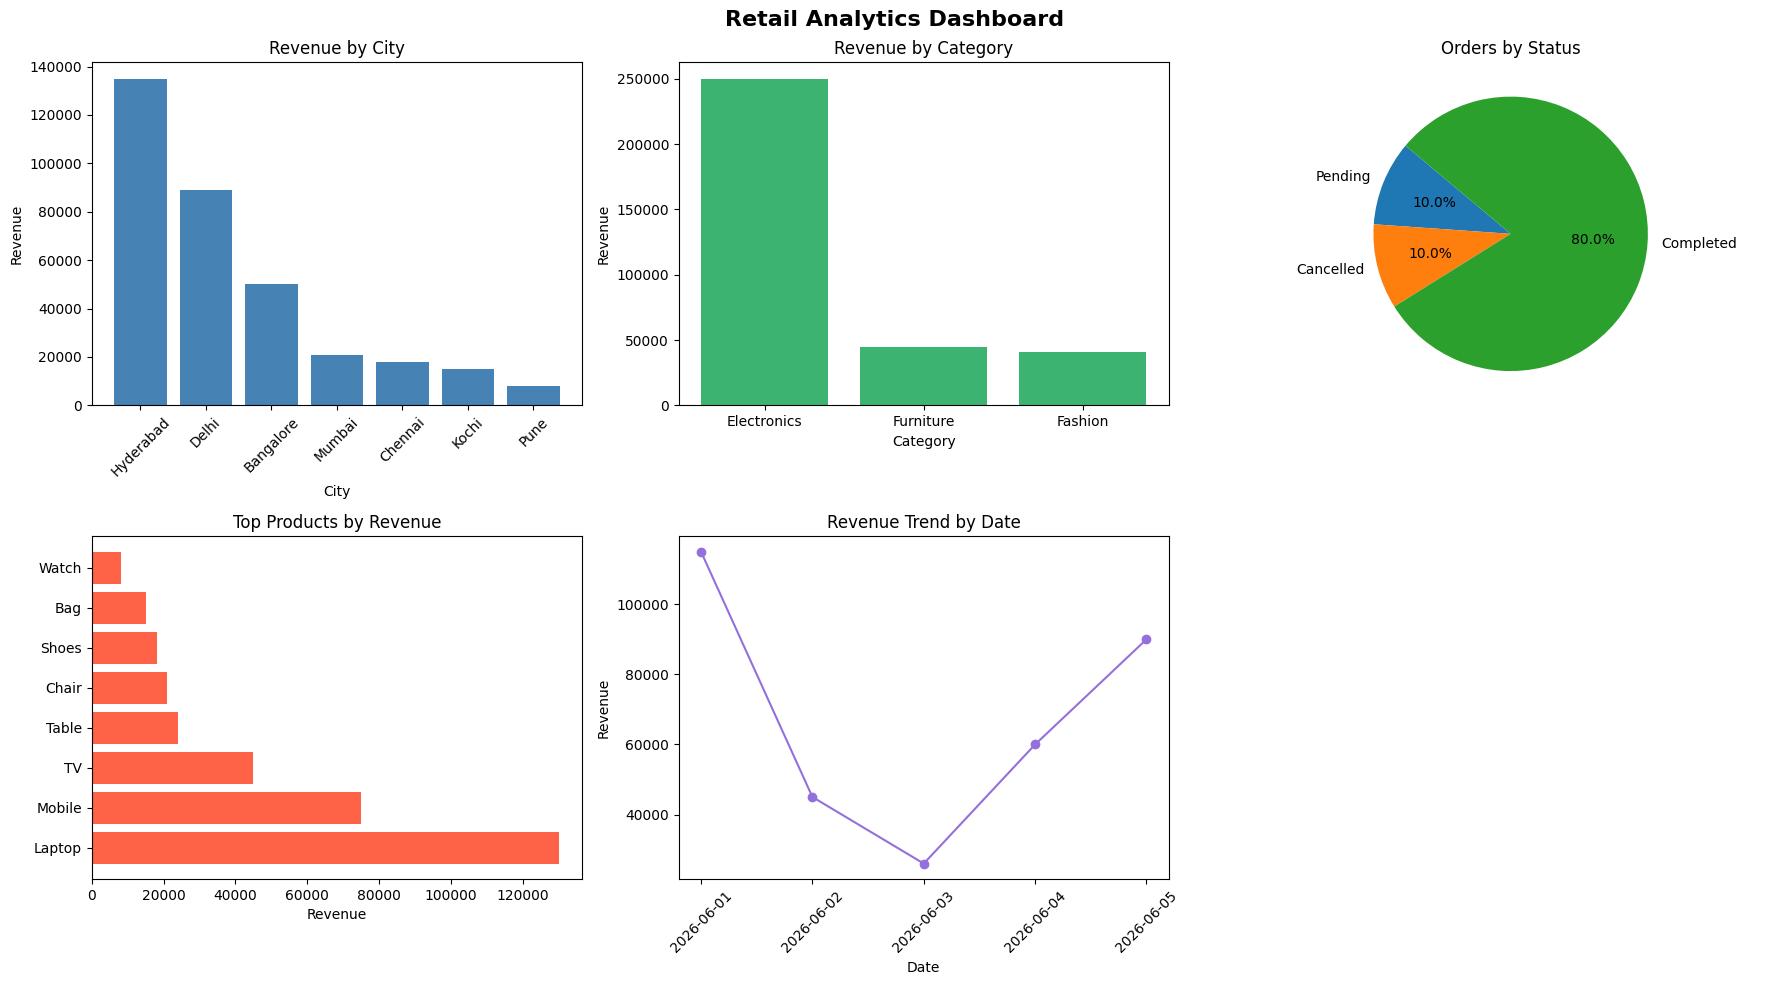

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, count

city_rev_pd = df_full.groupBy('customer_city').agg(spark_sum('revenue').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

cat_rev_pd = df_full.groupBy('category').agg(spark_sum('revenue').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

status_pd = df_full.groupBy('status').agg(count('order_id').alias('count')).toPandas()

prod_rev_pd = df_full.groupBy('product_name').agg(spark_sum('revenue').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

date_rev_pd = df_full.groupBy('order_date').agg(spark_sum('revenue').alias('revenue')) \
    .orderBy('order_date').toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#38 - Bar chart: Revenue by City
axes[0,0].bar(city_rev_pd['customer_city'], city_rev_pd['revenue'], color='steelblue')
axes[0,0].set_title('Revenue by City')
axes[0,0].set_xlabel('City')
axes[0,0].set_ylabel('Revenue')
axes[0,0].tick_params(axis='x', rotation=45)

#39 - Bar chart: Revenue by Category
axes[0,1].bar(cat_rev_pd['category'], cat_rev_pd['revenue'], color='mediumseagreen')
axes[0,1].set_title('Revenue by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Revenue')

#40 - Pie chart: Orders by Status
axes[0,2].pie(status_pd['count'], labels=status_pd['status'], autopct='%1.1f%%', startangle=140)
axes[0,2].set_title('Orders by Status')

#41 - Horizontal bar: Top Products by Revenue
axes[1,0].barh(prod_rev_pd['product_name'], prod_rev_pd['revenue'], color='tomato')
axes[1,0].set_title('Top Products by Revenue')
axes[1,0].set_xlabel('Revenue')

#42 - Line chart: Revenue Trend by Date
axes[1,1].plot(date_rev_pd['order_date'].astype(str), date_rev_pd['revenue'], marker='o', color='mediumpurple')
axes[1,1].set_title('Revenue Trend by Date')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Revenue')
axes[1,1].tick_params(axis='x', rotation=45)

axes[1,2].axis('off')

plt.suptitle('Retail Analytics Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 7: Tables and Views

In [0]:
#43 - Managed Table
spark.sql('DROP TABLE IF EXISTS customers_managed')
df_customers.write.format('delta').mode('overwrite').saveAsTable('customers_managed')
spark.sql('SELECT * FROM customers_managed').show()


+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
#44 - External Table (Unity Catalog compatible)
spark.sql('DROP TABLE IF EXISTS products_external')
spark.sql("""
    CREATE TABLE products_external
    USING DELTA
    AS SELECT * FROM products_view
""")
spark.sql('SELECT * FROM products_external').show()


+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
#45 - Temporary View
df_full.createOrReplaceTempView('orders_temp_view')
spark.sql('SELECT * FROM orders_temp_view LIMIT 5').show()


+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|customer_city|      state|customer_type|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|    Hyderabad|  Telangana|      Premium|      Laptop|Electronics|     65000|  65000|    2026-06|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|    Bangalore|  Karnataka|      Regular|      Mobile|Electronics|     25000|  50000|    2026-06|  Standard Value|
|      P103|       C103|   O1003|2026-06-02| 

In [0]:
#46 - Global Temporary View (not supported in Serverless - using Temp View instead)
df_full.createOrReplaceTempView('orders_global_view')
spark.sql('SELECT * FROM orders_global_view LIMIT 5').show()


+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|customer_city|      state|customer_type|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+-------------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|    Hyderabad|  Telangana|      Premium|      Laptop|Electronics|     65000|  65000|    2026-06|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|    Bangalore|  Karnataka|      Regular|      Mobile|Electronics|     25000|  50000|    2026-06|  Standard Value|
|      P103|       C103|   O1003|2026-06-02| 

In [0]:
#47 - Compare scope and lifetime of each
print("""
Table/View Comparison:
--------------------------------------------------------------
Managed Table      : Stored in Databricks metastore.
                     Data deleted when table is dropped.
                     Accessible across all sessions.

External Table     : Schema registered in metastore.
                     Data NOT deleted when table is dropped.
                     Points to external storage location.

Temporary View     : Exists only for current Spark session.
                     Dropped automatically when session ends.
                     Not accessible from other notebooks.

Global Temp View   : Available across notebooks in same cluster.
                     Dropped when cluster restarts.
                     Accessed via global_temp.<view_name>.
                     (Not supported in Serverless compute)
--------------------------------------------------------------
""")



Table/View Comparison:
--------------------------------------------------------------
Managed Table      : Stored in Databricks metastore.
                     Data deleted when table is dropped.
                     Accessible across all sessions.

External Table     : Schema registered in metastore.
                     Data NOT deleted when table is dropped.
                     Points to external storage location.

Temporary View     : Exists only for current Spark session.
                     Dropped automatically when session ends.
                     Not accessible from other notebooks.

Global Temp View   : Available across notebooks in same cluster.
                     Dropped when cluster restarts.
                     Accessed via global_temp.<view_name>.
                     (Not supported in Serverless compute)
--------------------------------------------------------------

